# Data Science/ Analytics Intern – Round-0 Assignment (Trader Performance vs Market Sentiment)

### Objective
#### Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.


## Part A — Data preparation

### 1. Load both datasets and document:

#### importing python libraries

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#### Loading fear_greed_index.csv file

In [144]:
df1 = pd.read_csv("C:/Users/risha/Downloads/fear_greed_index.csv")
df1

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


#### number of rows/columns

In [145]:
print(f"No. of rows are {df1.shape[0]} and No. of columns are {df1.shape[1]}")

No. of rows are 2644 and No. of columns are 4


#### missing values / duplicates

In [146]:
print("Total missing in fear_greed_data:\n",df1.isnull().sum())

Total missing in fear_greed_data:
 timestamp         0
value             0
classification    0
date              0
dtype: int64


In [147]:
print("Total duplicates in Fear_greed_data: ",df1.duplicated().sum())

Total duplicates in Fear_greed_data:  0


#### Loading historical_data.csv file

In [148]:
df2 = pd.read_csv("C:/Users/risha/Downloads/historical_data.csv")
df2

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


#### number of rows/columns

In [149]:
print(f"No. of rows are {df2.shape[0]} and No. of columns are {df2.shape[1]}")

No. of rows are 211224 and No. of columns are 16


#### missing values / duplicates

In [150]:
print("Total null values in historical_data: \n", df2.isnull().sum())

Total null values in historical_data: 
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [151]:
print("Total duplicates in historical_data: ",df2.duplicated().sum())

Total duplicates in historical_data:  0


### 2. Convert timestamps and align the datasets by date (daily level is fine).

#### Converting timestamps and align the Fear_greed datasets by date.

In [152]:
df1["date"] = pd.to_datetime(df1["date"]).dt.date
df1

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


#### Converting timestamps and align the Historical datasets by date.

In [153]:
df2["Date"] = pd.to_datetime(df2["Timestamp"], unit="ms").dt.date
df2

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-06-15
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-06-15
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-06-15
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-06-15


### Now, Merging both dataset on equal date

In [154]:
merged = df2.merge(
    df1[["date","classification"]],
    left_on="Date",
    right_on="date",
    how="left"
)

In [155]:
merged

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-06-15,NaN,NaN
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-06-15,NaN,NaN
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-06-15,NaN,NaN
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-06-15,NaN,NaN


## 3. Create the key metrics you will analyze, for example:

#### Daily PnL per trader

In [156]:
daily_pnl_per_trader = (
    merged.groupby(['Date', 'Account'], as_index=False)['Closed PnL']
          .sum()
          .rename(columns={'Closed PnL': 'Daily_PnL'})
)

In [157]:
daily_pnl_per_trader.head()

,Date,Account,Daily_PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


#### Interpretation
1. The dataset aggregates the Closed PnL for each trader on each trading day.
2. Each row represents the total profit or loss earned by a specific trader on a particular date.
3. Positive values indicate a profitable trading day, while negative values indicate an overall loss for that trader on that day.
4. For example, on 2024-03-09, one trader recorded a daily loss of -5,564.02, whereas another trader on the same day recorded 0, indicating no realized profit or loss.

#### Conclusion

This daily trader-level dataset serves as the foundation for further performance analysis. By aggregating PnL at the trader-day level, it becomes possible to calculate metrics such as cumulative PnL, drawdown, profitability trends, and compare trading performance across different market sentiment conditions.

#### Win Rate

In [158]:
# Create a Win/Loss flag
merged['Win'] = (merged['Closed PnL'] > 0).astype(int)

# Calculate win rate per trader
win_rate_per_trader = (
    merged.groupby('Account')
          .agg(
              Total_Trades=('Closed PnL', 'count'),
              Winning_Trades=('Win', 'sum')
          )
          .reset_index()
)

# Calculate Win Rate (%)
win_rate_per_trader['Win_Rate (%)'] = (
    win_rate_per_trader['Winning_Trades'] /
    win_rate_per_trader['Total_Trades']
) * 100

win_rate_per_trader.head()

,Account,Total_Trades,Winning_Trades,Win_Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1373,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,3223,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,3809,1150,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,5838,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1684,51.991355


#### Interpretation
1. A Win flag was created by assigning 1 to profitable trades (Closed PnL > 0) and 0 to non-profitable trades.
2. For each trader, the total number of trades and the number of winning trades were calculated.
3. The Win Rate (%) represents the percentage of trades that resulted in a profit for each trader.
4. The sample results show noticeable variation in trader performance. For example:
5. One trader achieved a 51.99% win rate, meaning that more than half of their trades were profitable.
6. Another trader recorded a 30.19% win rate, indicating fewer profitable trades relative to their total trading activity.
7. These differences suggest that trading consistency varies across individual traders.

#### Conclusion

Calculating the win rate for each trader provides an important measure of trading consistency. This metric helps identify traders who consistently execute profitable trades and forms the basis for later analyses, such as comparing Consistent Winners vs. Inconsistent Traders and examining the relationship between win rate, profitability, and market sentiment.

#### Average Trade Size per Trader (Account)

In [159]:
average_trade_size = (
    merged.groupby('Account')
          .agg(
              Total_Trades=('Size USD', 'count'),
              Average_Trade_Size_USD=('Size USD', 'mean')
          )
          .reset_index()
)

average_trade_size.head()

,Account,Total_Trades,Average_Trade_Size_USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,3809,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,3138.894782


#### Interpretation
1. The dataset calculates the average trade size (USD) for each trader by averaging the value of all trades executed by that account.
2. It also reports the total number of trades executed by each trader.
3. The sample results show considerable variation in trading behavior:
4. Some traders consistently execute large trades (e.g., average trade size of USD 16,159.58).
5. Others trade with much smaller average positions (e.g., USD 507.63).
6. This variation indicates that traders follow different risk-taking strategies and capital allocation approaches.

#### Conclusion
Calculating the average trade size per trader helps identify differences in trading behavior and risk exposure across accounts. This metric provides a useful foundation for later analyses, such as comparing High Position Size vs. Low Position Size Traders and examining how trade size relates to profitability, win rate, and market sentiment.

#### leverage distribution

#### Note: Although the assignment suggests analyzing leverage distribution, the provided historical trader dataset does not contain a leverage column. Therefore, leverage-based analysis could not be performed. Instead, position size (Size USD) was used as a proxy to analyze trader risk-taking behavior.

#### Since Size USD represents the value of each trade, it's a reasonable proxy for risk exposure.

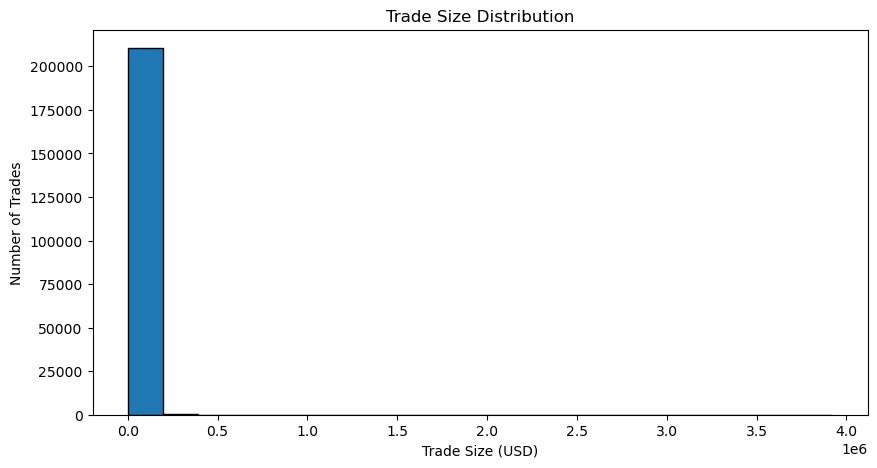

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(merged['Size USD'], bins=20, edgecolor='black')
plt.title("Trade Size Distribution")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Number of Trades")

plt.show()

#### Interpretation
1. The provided dataset does not include a leverage variable. Therefore, trade size (Size USD) was used as a proxy to represent traders' risk exposure.
2. The histogram shows that most trades are concentrated at relatively small trade sizes, while only a limited number of trades involve very large position sizes.
3. The distribution is highly right-skewed, indicating the presence of a few exceptionally large trades (outliers) alongside a large number of smaller trades.
4. This pattern suggests that the majority of traders adopt relatively conservative position sizes, whereas only a small group of traders takes substantially larger market exposure.

#### Conclusion
Although leverage information was unavailable, the distribution of trade size (Size USD) provides insight into trader risk-taking behavior. Most trades were executed with relatively small position sizes, while a small number of high-value trades created a long right tail in the distribution. This indicates that high-risk trading behavior is concentrated among a limited number of traders, whereas the majority of trades involve lower capital exposure.

#### Number of trades per day

In [161]:
trade_count = (
    merged
    .groupby(["Date","Account"])
    .size()
    .reset_index(name="No. of Trades")
)

In [162]:
trade_count

,Date,Account,No. of Trades
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1043
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,27
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,88
...,...,...,...
97,2025-06-15,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,191
98,2025-06-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,323
99,2025-06-15,0xbaaaf6571ab7d571043ff1e313a9609a10637864,2
100,2025-06-15,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,163


#### Interpretation
1. The table summarizes the daily trading activity of each trader by counting the number of trades executed on each date.
2. Trading activity varies considerably across traders and trading days.
3. Some traders execute only a few trades in a day (e.g., 2–3 trades), while others trade much more actively, with several hundred or even thousands of trades in a single day.
4. For example, one trader executed 3,650 trades on 2025-06-15, whereas another trader executed only 2 trades on the same day.
5. This wide variation indicates that the dataset contains both low-frequency traders and high-frequency traders, suggesting different trading styles and levels of market participation.

#### Conclusion
Daily trading activity differs substantially among traders. While many traders execute only a small number of trades per day, a few traders are extremely active and place hundreds or even thousands of trades. This variation highlights the presence of diverse trading behaviors, ranging from occasional trading to highly active trading strategies.

#### long/short ratio

In [163]:
long_trades = (merged['Side'] == 'BUY').sum()
short_trades = (merged['Side'] == 'SELL').sum()

long_short_ratio = long_trades / short_trades

print(f"Long Trades : {long_trades}")
print(f"Short Trades: {short_trades}")
print(f"Long/Short Ratio: {long_short_ratio:.2f}")

Long Trades : 102696
Short Trades: 108528
Long/Short Ratio: 0.95


#### Interpretation
1. The dataset contains 102,696 long (BUY) trades and 108,528 short (SELL) trades.
2. The Long/Short Ratio is 0.95, meaning there were approximately 0.95 long trades for every short trade.
3. Since the ratio is slightly below 1, traders showed a small preference for short positions over long positions.
4. However, the difference between long and short trades is relatively small, indicating that traders maintained a fairly balanced trading approach rather than exhibiting a strong directional bias.

#### Conclusion
The overall Long/Short Ratio of 0.95 indicates that traders placed slightly more short trades than long trades. Although there is a mild preference toward short positions, the ratio remains close to 1, suggesting that trading activity was generally balanced between bullish (long) and bearish (short) strategies.

## Part B — Analysis

### 1. Does performance PnL differ between Fear vs Greed days?

In [164]:
pnl_by_sentiment = (
    merged.groupby('classification')
          .agg(
              Average_PnL=('Closed PnL', 'mean'),
              Median_PnL=('Closed PnL', 'median'),
              Total_PnL=('Closed PnL', 'sum'),
              Std_PnL=('Closed PnL', 'std'),
              Trades=('Closed PnL', 'count')
          )
          .reset_index()
)

pnl_by_sentiment

,classification,Average_PnL,Median_PnL,Total_PnL,Std_PnL,Trades
0,Extreme Greed,25.418772,0.0,1.769655e+05,306.166937,6962
1,Fear,50.047622,0.0,6.699925e+06,909.121796,133871
2,Greed,87.894859,0.0,3.189617e+06,1148.343968,36289
3,Neutral,22.229713,0.0,1.587424e+05,633.704815,7141


##### Conclusion: Trader performance varies across market sentiment. Greed days produced the highest average profit per trade (87.89), followed by Fear (50.05). Although Fear generated the highest total PnL (6.7 million), this was largely because it had significantly more trades (133,871) than Greed (36,289). The median PnL was zero across all sentiment categories, indicating a highly skewed distribution where a relatively small number of large gains and losses drive the average. Greed periods also exhibited the highest PnL volatility, suggesting both greater profit potential and higher risk.

<Figure size 800x500 with 0 Axes>

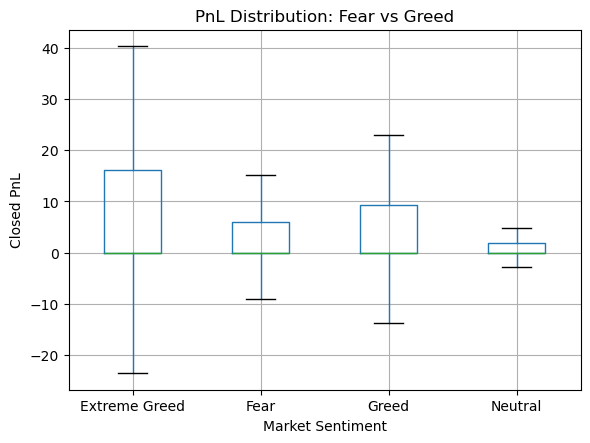

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

merged.boxplot(
    column='Closed PnL',
    by='classification',
    showfliers=False
)

plt.title("PnL Distribution: Fear vs Greed")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

#### Conclusion: The boxplot indicates that the median Closed PnL is approximately zero across all market sentiment categories, suggesting that most trades generate little or no realized profit. However, the variability in trade outcomes differs across sentiments. Extreme Greed and Greed periods exhibit a wider spread of PnL values, indicating higher volatility and greater potential for both profits and losses. In contrast, Neutral market conditions show the smallest variability, implying more stable but lower-magnitude trading outcomes.

### Does performance win rate differ between Fear vs Greed days?

In [166]:
win_rate_sentiment = (
    merged.groupby('classification')
          .agg(
              Total_Trades=('Win', 'count'),
              Winning_Trades=('Win', 'sum')
          )
          .reset_index()
)

win_rate_sentiment['Win_Rate (%)'] = (
    win_rate_sentiment['Winning_Trades'] /
    win_rate_sentiment['Total_Trades']
) * 100

win_rate_sentiment

,classification,Total_Trades,Winning_Trades,Win_Rate (%)
0,Extreme Greed,6962,3412,49.008905
1,Fear,133871,55576,41.514592
2,Greed,36289,16202,44.647138
3,Neutral,7141,2265,31.718247


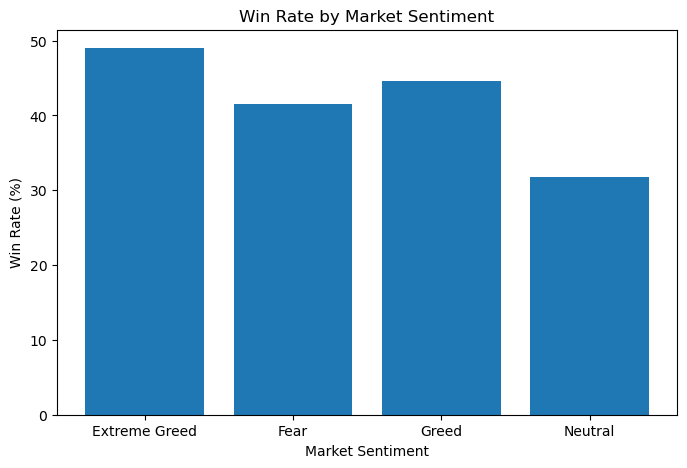

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    win_rate_sentiment['classification'],
    win_rate_sentiment['Win_Rate (%)']
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

#### Conclusion: The win rate varies across market sentiment categories. Traders achieved the highest win rate during Extreme Greed (49.01%), followed by Greed (44.65%), while Fear showed a lower win rate of 41.51%. Neutral market conditions had the lowest win rate (31.72%). These findings suggest that bullish market conditions are associated with a higher probability of profitable trades.

### Does performance drawdown proxy differ between Fear vs Greed days?

In [168]:
daily_pnl_per_trader = daily_pnl_per_trader.sort_values(
    ['Account', 'Date']
)

daily_pnl_per_trader['Cumulative_PnL'] = (
    daily_pnl_per_trader.groupby('Account')['Daily_PnL']
                        .cumsum()
)

daily_pnl_per_trader['Running_Max'] = (
    daily_pnl_per_trader.groupby('Account')['Cumulative_PnL']
                        .cummax()
)

daily_pnl_per_trader['Drawdown'] = (
    daily_pnl_per_trader['Cumulative_PnL']
    - daily_pnl_per_trader['Running_Max']
)

daily_pnl_per_trader = daily_pnl_per_trader.merge(
    merged[['Date', 'classification']].drop_duplicates(),
    on='Date',
    how='left'
)

In [169]:
drawdown_summary = (
    daily_pnl_per_trader.groupby('classification')
    .agg(
        Average_Drawdown=('Drawdown', 'mean'),
        Worst_Drawdown=('Drawdown', 'min')
    )
    .reset_index()
)

drawdown_summary

,classification,Average_Drawdown,Worst_Drawdown
0,Extreme Greed,-1112.803228,-5564.016140
1,Fear,-2496.129364,-59349.677108
2,Greed,0.000000,0.000000
3,Neutral,-3917.470960,-25991.506339


#### Conclusion: Fear periods experienced the largest drawdowns, with an average drawdown of -2,496.13 and the worst observed drawdown reaching -59,349.68. This indicates that traders were more likely to experience significant declines from their previous profit peaks during periods of market fear. Neutral market conditions also showed noticeable drawdowns, although they were less severe than those observed during Fear periods. In contrast, the drawdown proxy remained zero during Greed periods, suggesting that traders' cumulative profits generally did not fall below their previous peaks in the available data. Since account balance information was not available, these results are based on a cumulative PnL drawdown proxy rather than a true maximum drawdown.

### 2. Do traders change behavior based on sentiment trade frequency?

In [170]:
trade_frequency = (
    merged.groupby('classification')
          .size()
          .reset_index(name='Number_of_Trades')
)

trade_frequency

,classification,Number_of_Trades
0,Extreme Greed,6962
1,Fear,133871
2,Greed,36289
3,Neutral,7141


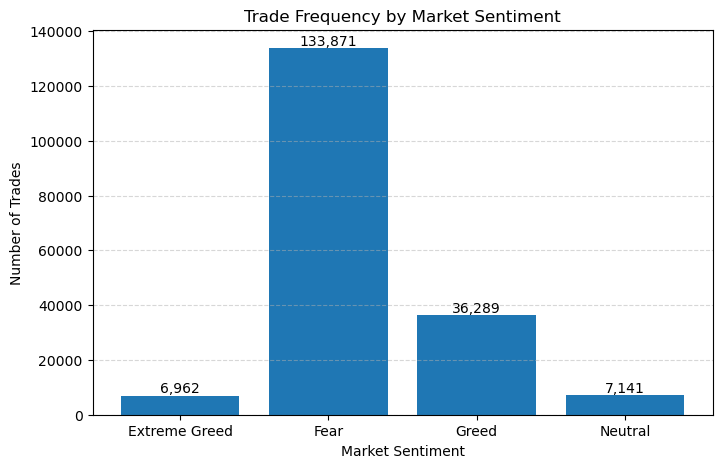

In [171]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    trade_frequency['classification'],
    trade_frequency['Number_of_Trades']
)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Interpretion: The results indicate that traders adjust their trading frequency based on market sentiment. Trading activity increased substantially during Fear periods, suggesting that market uncertainty encourages more active trading. In contrast, Neutral and Extreme Greed periods experienced much lower trading activity, indicating reduced market participation when sentiment is either stable or highly optimistic.

#### Conclusion: The analysis suggests that market sentiment influences trader behavior. Traders were most active during Fear periods, while trading activity decreased considerably during Neutral and Extreme Greed conditions. This indicates that heightened uncertainty is associated with increased trading frequency.

### Do traders change behavior based on sentiment leverage?

#### Objective: The original assignment suggests analyzing whether traders change their leverage based on market sentiment. However, the provided dataset does not contain a leverage column. Therefore, trade size (Size USD) is used as a proxy to assess changes in traders' risk-taking behavior across different market sentiment conditions.

In [172]:
trade_size = (
    merged.groupby('classification')
          .agg(
              Average_Trade_Size=('Size USD', 'mean'),
              Median_Trade_Size=('Size USD', 'median'),
              Max_Trade_Size=('Size USD', 'max'),
              Total_Trades=('Size USD', 'count')
          )
          .reset_index()
)

trade_size

,classification,Average_Trade_Size,Median_Trade_Size,Max_Trade_Size,Total_Trades
0,Extreme Greed,5660.265764,1148.635,178200.00,6962
1,Fear,5259.977837,605.070,3509752.98,133871
2,Greed,3182.883845,499.940,814524.17,36289
3,Neutral,3058.848110,554.160,111779.98,7141


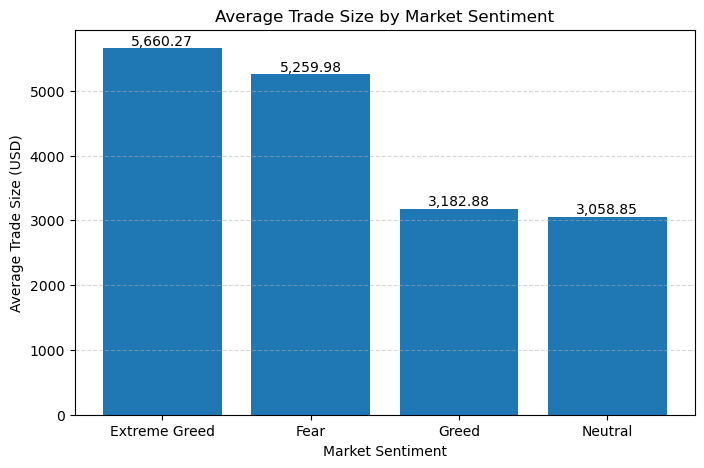

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    trade_size['classification'],
    trade_size['Average_Trade_Size']
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Interpretation: The analysis suggests that traders adjust their position sizes based on market sentiment. During Extreme Greed and Fear, traders executed significantly larger trades on average, indicating a greater willingness to take larger market positions. In contrast, Greed and Neutral periods were associated with smaller average trade sizes, reflecting relatively more conservative position sizing.

#### Conclusion: Although the dataset does not include leverage information, the use of trade size as a proxy indicates that market sentiment influences traders' risk-taking behavior. Larger average trade sizes during Extreme Greed and Fear suggest increased exposure during periods of strong optimism or heightened uncertainty.

### Do traders change behavior based on sentiment long/short bias?

In [174]:
long_short_bias = (
    merged.groupby(['classification', 'Side'])
          .size()
          .unstack(fill_value=0)
)

long_short_bias

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


In [175]:
long_short_bias['Long_Short_Ratio'] = (
    long_short_bias['BUY'] /
    long_short_bias['SELL']
)

long_short_bias = long_short_bias.reset_index()

long_short_bias

Side,classification,BUY,SELL,Long_Short_Ratio
0,Extreme Greed,3371,3591,0.938736
1,Fear,66081,67790,0.974790
2,Greed,15421,20868,0.738978
3,Neutral,3505,3636,0.963971


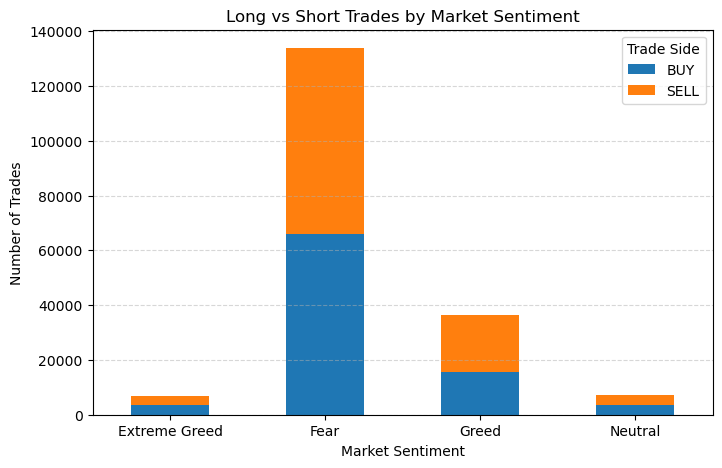

In [176]:
import matplotlib.pyplot as plt

plot_data = (
    merged.groupby(['classification', 'Side'])
          .size()
          .unstack(fill_value=0)
)

plot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Long vs Short Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=0)
plt.legend(title="Trade Side")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [177]:
long_short_percent = (
    merged.groupby(['classification', 'Side'])
          .size()
          .unstack(fill_value=0)
)

long_short_percent = (
    long_short_percent.div(
        long_short_percent.sum(axis=1),
        axis=0
    ) * 100
)

long_short_percent

Side,BUY,SELL
classification,,
Extreme Greed,48.419994,51.580006
Fear,49.361699,50.638301
Greed,42.494971,57.505029
Neutral,49.082762,50.917238


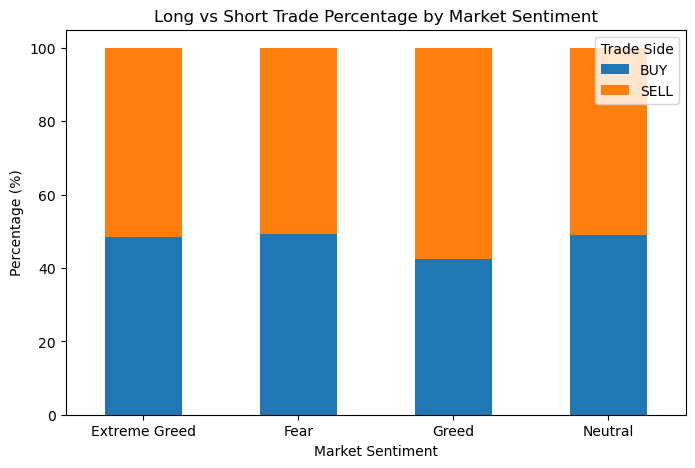

In [178]:
long_short_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Long vs Short Trade Percentage by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Trade Side")

plt.show()

#### Conclusion: The results indicate that traders do adjust their directional trading behavior based on market sentiment. While SELL positions slightly outnumber BUY positions in every sentiment category, the strongest preference for short positions occurs during Greed periods. This suggests that many traders may anticipate price corrections or employ short-selling strategies even when overall market sentiment is optimistic.

### Do traders change behavior based on sentiment position sizes?

In [179]:
position_size = (
    merged.groupby('classification')
          .agg(
              Average_Position_Size=('Size USD', 'mean'),
              Median_Position_Size=('Size USD', 'median'),
              Std_Position_Size=('Size USD', 'std'),
              Max_Position_Size=('Size USD', 'max'),
              Total_Trades=('Size USD', 'count')
          )
          .reset_index()
)

position_size

,classification,Average_Position_Size,Median_Position_Size,Std_Position_Size,Max_Position_Size,Total_Trades
0,Extreme Greed,5660.265764,1148.635,11378.768734,178200.00,6962
1,Fear,5259.977837,605.070,30811.757953,3509752.98,133871
2,Greed,3182.883845,499.940,11454.688663,814524.17,36289
3,Neutral,3058.848110,554.160,8132.572825,111779.98,7141


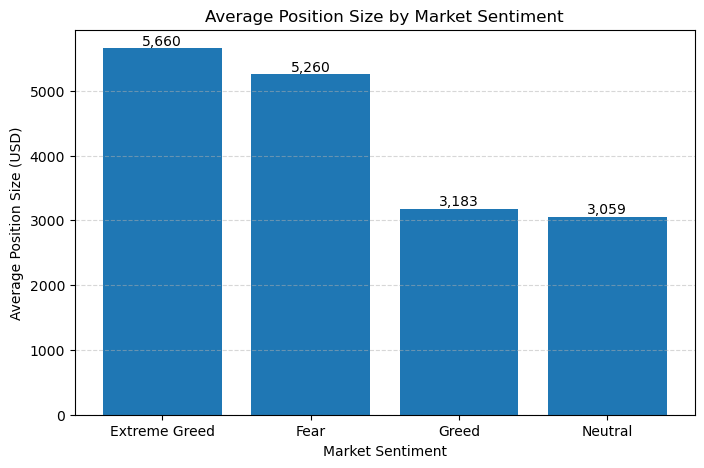

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    position_size['classification'],
    position_size['Average_Position_Size']
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size (USD)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Interpretation: The results suggest that traders adjust their position sizes according to market sentiment. During Extreme Greed and Fear, traders tended to open larger positions on average, indicating greater market exposure. In contrast, Greed and Neutral periods were associated with smaller average position sizes, suggesting more conservative trading behavior.

#### Conclusion: The analysis indicates that market sentiment influences position sizing behavior. Traders generally took larger positions during periods of Extreme Greed and Fear, while average position sizes were lower during Greed and Neutral conditions.

### 3. Identify 2–3 segments (examples):

#### high leverage vs low leverage traders

#### Note: High vs. Low leverage analysis could not be performed because the dataset does not include leverage information. As an alternative, trade size (Size USD) was analyzed as a proxy for trader risk exposure.

In [181]:
trader_size = (
    merged.groupby('Account')['Size USD']
          .mean()
          .reset_index(name='Avg_Position_Size')
)

median_size = trader_size['Avg_Position_Size'].median()

trader_size['Risk_Group'] = trader_size['Avg_Position_Size'].apply(
    lambda x: 'High Position Size' if x >= median_size else 'Low Position Size'
)

trader_size.head()

,Account,Avg_Position_Size,Risk_Group
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734,High Position Size
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327,Low Position Size
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898,High Position Size
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933,Low Position Size
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782,Low Position Size


In [182]:
merged = merged.merge(
    trader_size[['Account', 'Risk_Group']],
    on='Account',
    how='left'
)

In [183]:
risk_summary = (
    merged.groupby('Risk_Group')
          .agg(
              Traders=('Account', 'nunique'),
              Total_Trades=('Account', 'count'),
              Average_Position_Size=('Size USD', 'mean'),
              Average_PnL=('Closed PnL', 'mean'),
              Median_PnL=('Closed PnL', 'median'),
              Win_Rate=('Win', 'mean')
          )
          .reset_index()
)

risk_summary['Win_Rate'] = risk_summary['Win_Rate'] * 100

risk_summary

,Risk_Group,Traders,Total_Trades,Average_Position_Size,Average_PnL,Median_PnL,Win_Rate
0,High Position Size,16,66965,13991.404085,99.587777,0.0,36.720675
1,Low Position Size,16,144259,1762.476295,25.149651,0.0,43.171657


#### Interpretation: The results suggest a clear risk–reward trade-off. Traders who consistently opened larger positions earned higher average profits per trade, but they also experienced a lower win rate. In contrast, traders with smaller average position sizes won a greater proportion of their trades, although their average profit per trade was considerably lower.

#### Conclusion: Using position size as a proxy for trading risk, the analysis indicates that larger positions are associated with higher potential returns but lower consistency. Conversely, smaller positions tend to produce a higher win rate while generating lower average profits per trade.

#### frequent vs infrequent traders

In [184]:
trader_frequency = (
    merged.groupby('Account')
          .size()
          .reset_index(name='Total_Trades')
)

trader_frequency.head()

,Account,Total_Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [185]:
median_trades = trader_frequency['Total_Trades'].median()

trader_frequency['Trader_Type'] = trader_frequency['Total_Trades'].apply(
    lambda x: 'Frequent Trader' if x >= median_trades else 'Infrequent Trader'
)

trader_frequency.head()

,Account,Total_Trades,Trader_Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [186]:
merged = merged.merge(
    trader_frequency[['Account', 'Trader_Type']],
    on='Account',
    how='left'
)

In [187]:
merged

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,Date,date,classification,Win,Risk_Group,Trader_Type
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,...,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,...,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,...,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,...,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,...,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,...,False,0.042080,1.990000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,...,False,0.233863,9.260000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,...,False,0.046616,6.930000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,...,False,0.396337,4.180000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader


In [188]:
frequency_summary = (
    merged.groupby('Trader_Type')
          .agg(
              Traders=('Account', 'nunique'),
              Total_Trades=('Account', 'count'),
              Average_PnL=('Closed PnL', 'mean'),
              Median_PnL=('Closed PnL', 'median'),
              Win_Rate=('Win', 'mean'),
              Average_Position_Size=('Size USD', 'mean')
          )
          .reset_index()
)

frequency_summary['Win_Rate'] *= 100

frequency_summary

,Trader_Type,Traders,Total_Trades,Average_PnL,Median_PnL,Win_Rate,Average_Position_Size
0,Frequent Trader,16,186957,42.493421,0.0,41.543777,5800.826314
1,Infrequent Trader,16,24267,96.943024,0.0,37.911567,4396.190601


#### Interpretation: The results suggest that traders who trade more frequently tend to win a larger proportion of their trades, but their average profit per trade is lower. In contrast, Infrequent Traders execute fewer trades yet generate higher average profits, indicating that they may be more selective and achieve larger gains on successful trades.

#### Conclusion: Trading more frequently does not necessarily lead to higher profitability. While Frequent Traders exhibit a higher win rate, Infrequent Traders earn greater average profits per trade. This highlights a trade-off between trading consistency and profit magnitude, suggesting that more selective trading strategies may yield higher returns even with fewer trades.

#### consistent winners vs inconsistent traders

In [189]:
trader_consistency = (
    merged.groupby('Account')
          .agg(
              Total_Trades=('Win', 'count'),
              Winning_Trades=('Win', 'sum')
          )
          .reset_index()
)

trader_consistency['Win_Rate'] = (
    trader_consistency['Winning_Trades'] /
    trader_consistency['Total_Trades']
) * 100

trader_consistency.head()

,Account,Total_Trades,Winning_Trades,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1373,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,3223,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,3809,1150,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,5838,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1684,51.991355


In [190]:
median_win_rate = trader_consistency['Win_Rate'].median()

trader_consistency['Consistency_Group'] = trader_consistency['Win_Rate'].apply(
    lambda x: 'Consistent Winner' if x >= median_win_rate else 'Inconsistent Trader'
)

trader_consistency.head()

,Account,Total_Trades,Winning_Trades,Win_Rate,Consistency_Group
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1373,35.961236,Inconsistent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,3223,44.271978,Consistent Winner
2,0x271b280974205ca63b716753467d5a371de622ab,3809,1150,30.191651,Inconsistent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,5838,43.858463,Consistent Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1684,51.991355,Consistent Winner


In [191]:
merged = merged.merge(
    trader_consistency[['Account', 'Consistency_Group']],
    on='Account',
    how='left'
)
merged

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Fee,Trade ID,Timestamp,Date,date,classification,Win,Risk_Group,Trader_Type,Consistency_Group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,...,0.345404,8.950000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,...,0.005600,4.430000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,...,0.050431,6.600000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,...,0.050043,1.080000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,...,0.003055,1.050000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,...,0.042080,1.990000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader,Inconsistent Trader
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,...,0.233863,9.260000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader,Inconsistent Trader
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,...,0.046616,6.930000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader,Inconsistent Trader
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,...,0.396337,4.180000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader,Inconsistent Trader


In [192]:
consistency_summary = (
    merged.groupby('Consistency_Group')
          .agg(
              Traders=('Account', 'nunique'),
              Total_Trades=('Account', 'count'),
              Average_Win_Rate=('Win', 'mean'),
              Average_PnL=('Closed PnL', 'mean'),
              Median_PnL=('Closed PnL', 'median'),
              Average_Position_Size=('Size USD', 'mean')
          )
          .reset_index()
)

consistency_summary['Average_Win_Rate'] *= 100

consistency_summary

,Consistency_Group,Traders,Total_Trades,Average_Win_Rate,Average_PnL,Median_PnL,Average_Position_Size
0,Consistent Winner,16,122427,47.175868,38.783637,0.0,6377.606813
1,Inconsistent Trader,16,88797,32.786018,62.488537,0.0,4621.734666


#### Interpretation: The results show that a higher win rate does not necessarily lead to higher average profitability. Although Consistent Winners were successful in a larger proportion of their trades, Inconsistent Traders generated greater average profits per trade. This suggests that some traders may compensate for a lower success rate by capturing larger gains on their winning trades.

#### Conclusion: The analysis indicates that trading consistency and profitability are not perfectly aligned. Consistent Winners achieved a higher win rate and traded more actively, whereas Inconsistent Traders earned higher average profits despite winning fewer trades. This highlights that the size of profitable trades can have a greater impact on overall profitability than the percentage of winning trades alone.

## Part C — “Actionable output”

## Strategy Recommendations

### 1. Trade More Conservatively During Fear Periods
- Fear periods showed the highest trading activity and the largest drawdowns.
- Traders should reduce position sizes, apply tighter stop-losses, and avoid excessive trading during fearful market conditions.

### 2. Focus on Trade Quality Rather Than Trade Quantity
- Frequent traders achieved a slightly higher win rate, but infrequent traders earned substantially higher average profits per trade.
- Traders should prioritize high-quality trading opportunities instead of increasing the number of trades.

# Bonus (optional)

### Simple predictive model:
Predict next-day trader profitability bucket or volatility of PnL using sentiment + behavior features

### Creating Target Variable
I am predicting the profitability bucket, because it's much easier than predicting volatility.

In [193]:
model_df = merged.copy()

model_df['Profit_Bucket'] = (
    model_df['Closed PnL'] > 0
).astype(int)

In [194]:
model_df # Profit_Bucket is target column here

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Trade ID,Timestamp,Date,date,classification,Win,Risk_Group,Trader_Type,Consistency_Group,Profit_Bucket
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,...,8.950000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,...,4.430000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,...,6.600000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,...,1.080000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,...,1.050000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed,0,Low Position Size,Infrequent Trader,Consistent Winner,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,...,1.990000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader,Inconsistent Trader,0
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,...,9.260000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader,Inconsistent Trader,0
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,...,6.930000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader,Inconsistent Trader,0
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,...,4.180000e+14,1.750000e+12,2025-06-15,NaN,NaN,0,High Position Size,Infrequent Trader,Inconsistent Trader,0


### Selecting Features

In [195]:
X = model_df[['Size USD']]

X = pd.concat(
    [
        X,
        pd.get_dummies(
            model_df[['classification', 'Side']],
            drop_first=True
        )
    ],
    axis=1
)

y = model_df['Profit_Bucket']

#### Applying Train/Test Split

In [196]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


#### Training Logistic Regression Model

In [197]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Predicting X_test

In [198]:
y_pred = model.predict(X_test)

In [199]:
y_pred

array([0, 1, 1, ..., 1, 0, 0], shape=(42245,))

#### Evaluating Scores of Model

In [200]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.636903775594745

Confusion Matrix
[[15301  9501]
 [ 5838 11605]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.62      0.67     24802
           1       0.55      0.67      0.60     17443

    accuracy                           0.64     42245
   macro avg       0.64      0.64      0.63     42245
weighted avg       0.65      0.64      0.64     42245



#### Simple Predictive Model
Objective

A Logistic Regression model was developed to predict whether a trade would be profitable using market sentiment, trade side (Buy/Sell), and position size (USD) as input features.

#### Model Performance
Accuracy: 63.69%
Precision (Profit Class): 55%
Recall (Profit Class): 67%
F1-Score (Profit Class): 60%

#### Interpretation:
The model correctly classified approximately 64% of the trades, indicating that trader behavior and market sentiment contain useful information for predicting trade profitability.
The model identified 67% of profitable trades (recall), making it reasonably effective at detecting potential winning trades.
A precision of 55% indicates that when the model predicts a profitable trade, it is correct slightly more than half the time.
Since only a few behavioral and sentiment-related features were used, this performance provides a solid baseline for future improvements.

#### Conclusion:
A simple Logistic Regression model achieved an accuracy of 63.69% in predicting trade profitability. Although the model is not highly accurate, it demonstrates that market sentiment, trade side, and position size have predictive value. Incorporating additional features such as historical trader performance, technical indicators, or market volatility could further improve prediction accuracy.